# **A MULTI-HAZARD SCREENING FRAMEWORK FOR SHALLOW LANDSLIDES AND FLOODS IN NORWAY**

This project presents a municipality-level multi-hazard dashboard for Norway that combines model-based shallow landslide probability, flood exposure, and a relative multi-hazard index. It uses geospatial processing, machine learning, and local model interpretation to compare relative hazard patterns across municipalities. The dashboard also includes plain-language explanations to make the results easier to understand.

kommunenummer — municipality identifier (code), stored as string for stable joins.

kommunenavn — municipality name (label).

share_bedrock — area share of bedrock class within municipality: area(bedrock ∩ municipality) / area(municipality).

share_weathering — area share of weathering deposits: area(weathering ∩ municipality) / area(municipality).

share_moraine — area share of moraine deposits: area(moraine ∩ municipality) / area(municipality).

share_clay — area share of clay class: area(clay ∩ municipality) / area(municipality).

share_marine — area share of marine deposits: area(marine ∩ municipality) / area(municipality).

share_organic — area share of organic deposits: area(organic ∩ municipality) / area(municipality).

share_fluvial_flood — area share of fluvial/floodplain-related deposits: area(fluvial_flood ∩ municipality) / area(municipality).

share_glaciofluvial — area share of glaciofluvial deposits: area(glaciofluvial ∩ municipality) / area(municipality).

share_mass_movement — area share of mass-movement deposits: area(mass_movement ∩ municipality) / area(municipality).

share_anthro — area share of anthropogenic deposits/surfaces: area(anthro ∩ municipality) / area(municipality).

share_water — area share of water surfaces: area(water ∩ municipality) / area(municipality).

share_unknown — area share of unmapped/unknown class: area(unknown ∩ municipality) / area(municipality).

share_sum — total share covered by the selected classes, computed in QGIS as a NULL-safe sum:
coalesce(share_bedrock,0) + coalesce(share_weathering,0) + … + coalesce(share_unknown,0).
(Should be close to 1.0 if the selected classes fully partition the municipality area.)

share_other — residual share: 1 − share_sum (if used). (If share_sum is ~1, share_other should be ~0.)

elev_mean — mean elevation (meters) within municipality polygon from DEM via zonal statistics.

elev_stdev — standard deviation of elevation (meters) within municipality.

relief — elevation range (meters): elev_max − elev_min, computed from zonal statistics (max/min) on the DEM.

slp_mean — mean slope (degrees) within municipality from slope raster (GDAL slope, AS_PERCENT=False).

slp_stdev — standard deviation of slope (degrees).

slp_max — maximum slope (degrees).

slp_range — slope range (degrees): slp_max − slp_min (if computed), noting that slp_min is often near 0 so range can approximate max.

Yi_shallow — binary target: 1 if municipality has ≥1 recorded shallow landslide event in the study window (e.g., 2014–2023), else 0.

geometry — municipality polygon geometry (not used as ML feature; used for mapping/spatial ops).

geometry_bbox — geometry bounding box (technical metadata; not used as ML feature).

# Imports

In [49]:
!pip install matplotlib-scalebar

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib
import os
import shap
import json
import time
import re

from openai import OpenAI
from matplotlib_scalebar.scalebar import ScaleBar
import geopandas as gpd

from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score, average_precision_score, brier_score_loss

pd.set_option('float_format', '{:.3f}'.format)

In [ ]:
df = pd.read_parquet("../data/interim/model_dataset_loss_elev_slp_yi.parquet")

# 1. Exploratory Data Analysis

## Municipal feature table (terrain + deposits + label)

In [52]:
df

,kommunenummer,kommunenavn,share_bedrock,share_weathering,share_moraine,share_marine,share_organic,share_fluvial_flood,share_glaciofluvial,share_mass_movement,...,elev_mean,elev_stdev,relief,slp_mean,slp_stdev,slp_max,slp_range,Yi_shallow,geometry,geometry_bbox
0,3419,Våler,0.011,NaN,NaN,NaN,0.109,0.041,0.077,NaN,...,378.452,123.855,556.600,4.363,3.664,39.978,39.978,1,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,"{'xmin': 315023.96875, 'ymin': 6718857.0, 'xma..."
1,3326,Hemsedal,0.082,0.289,NaN,NaN,0.065,0.028,NaN,0.054,...,1175.513,285.262,1350.600,12.659,10.056,71.135,71.135,1,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,"{'xmin': 122837.296875, 'ymin': 6752852.5, 'xm..."
2,4622,Kvam,0.713,0.177,NaN,NaN,0.008,0.008,0.002,0.033,...,486.513,374.848,1331.100,14.049,12.642,72.338,72.338,1,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,"{'xmin': -7165.78076171875, 'ymin': 6697608.5,..."
3,5054,Indre Fosen,0.195,0.063,NaN,NaN,NaN,0.010,NaN,NaN,...,193.172,151.153,621.500,8.422,8.500,58.133,58.133,1,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,"{'xmin': 240072.703125, 'ymin': 7045760.0, 'xm..."
4,4617,Kvinnherad,0.778,0.030,NaN,NaN,0.001,0.008,0.004,0.037,...,452.436,477.157,1646.700,13.589,13.964,74.768,74.768,1,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,"{'xmin': -28117.91015625, 'ymin': 6653283.0, '..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,4202,Grimstad,0.277,NaN,NaN,NaN,NaN,0.001,0.008,0.000,...,38.502,76.196,361.800,2.710,5.524,52.899,52.899,1,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,"{'xmin': 109244.46875, 'ymin': 6454824.0, 'xma..."
353,3103,Moss,0.521,NaN,0.019,NaN,NaN,0.000,NaN,0.000,...,18.274,22.385,138.000,1.884,3.099,33.548,33.548,1,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,"{'xmin': 246920.75, 'ymin': 6580710.5, 'xmax':..."
354,3207,Nordre Follo,0.435,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,137.433,50.626,312.300,5.102,4.317,40.726,40.726,1,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,"{'xmin': 259802.28125, 'ymin': 6616156.0, 'xma..."
355,3118,Indre Østfold,0.325,NaN,NaN,NaN,NaN,0.003,NaN,NaN,...,149.084,47.493,304.300,4.579,3.814,31.358,31.358,1,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,"{'xmin': 261055.78125, 'ymin': 6595979.5, 'xma..."


In [53]:
df.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   kommunenummer        357 non-null    object 
 1   kommunenavn          357 non-null    object 
 2   share_bedrock        354 non-null    float64
 3   share_weathering     112 non-null    float64
 4   share_moraine        15 non-null     float64
 5   share_marine         29 non-null     float64
 6   share_organic        125 non-null    float64
 7   share_fluvial_flood  299 non-null    float64
 8   share_glaciofluvial  187 non-null    float64
 9   share_mass_movement  104 non-null    float64
 10  share_anthro         187 non-null    float64
 11  share_water          162 non-null    float64
 12  share_unknown        9 non-null      float64
 13  share_clay           9 non-null      float64
 14  share_sum            357 non-null    float64
 15  share_other          357 non-null    flo

In [54]:
df.describe()

,share_bedrock,share_weathering,share_moraine,share_marine,share_organic,share_fluvial_flood,share_glaciofluvial,share_mass_movement,share_anthro,share_water,...,share_sum,share_other,elev_mean,elev_stdev,relief,slp_mean,slp_stdev,slp_max,slp_range,Yi_shallow
count,354.000,112.000,15.000,29.000,125.000,299.000,187.000,104.000,187.000,162.000,...,357.000,357.000,337.000,337.000,337.000,337.000,337.000,337.000,337.000,357.000
mean,0.346,0.042,0.022,0.031,0.046,0.011,0.010,0.014,0.005,0.070,...,0.428,0.572,376.864,182.446,950.351,8.020,7.824,58.918,58.918,0.899
std,0.235,0.080,0.038,0.092,0.060,0.012,0.014,0.026,0.016,0.100,...,0.237,0.237,335.566,115.648,527.138,4.723,3.406,14.501,14.501,0.302
min,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.008,0.000,0.060,1.003,25.800,0.028,0.529,12.097,12.097,0.000
25%,0.159,0.001,0.001,0.001,0.005,0.003,0.002,0.000,0.000,0.008,...,0.251,0.407,88.320,87.882,511.400,4.389,5.515,49.663,49.663,1.000
50%,0.325,0.010,0.005,0.001,0.016,0.008,0.005,0.003,0.000,0.034,...,0.410,0.590,268.311,175.735,923.200,7.711,7.356,62.629,62.629,1.000
75%,0.496,0.051,0.020,0.008,0.066,0.017,0.011,0.012,0.002,0.085,...,0.593,0.749,596.032,246.019,1332.300,11.219,10.528,69.974,69.974,1.000
max,0.931,0.575,0.120,0.479,0.248,0.067,0.115,0.159,0.142,0.558,...,1.000,0.992,1406.752,560.041,2386.600,22.739,15.909,83.195,83.195,1.000


In [55]:
df['share_sum'].describe()

,share_sum
count,357.000
mean,0.428
std,0.237
min,0.008
25%,0.251
50%,0.410
75%,0.593
max,1.000


In [56]:
df['share_sum'].max()

0.999999

In [57]:
# pick share columns
share_cols = [
    c for c in df.columns
    if c.startswith("share_") and c not in ("share_sum", "share_other")
]

# row-wise sum with NaN treated as 0
row_sum = df[share_cols].fillna(0).sum(axis=1)

# maximum absolute difference vs stored share_sum
max_abs_diff = (row_sum - df["share_sum"]).abs().max()

print(f"Number of share_* components used: {len(share_cols)}")
print(f"max_abs_diff = {max_abs_diff:.12g}")


worst = (row_sum - df["share_sum"]).abs().sort_values(ascending=False).head(10)
print("\nTop 10 rows by |row_sum - share_sum|:")
print(df.loc[worst.index, ["kommunenummer", "kommunenavn", "share_sum"]].assign(row_sum=row_sum.loc[worst.index],
                                                                              abs_diff=worst.values))

Number of share_* components used: 12
max_abs_diff = 2.22044604925e-16

Top 10 rows by |row_sum - share_sum|:
    kommunenummer  kommunenavn  share_sum  row_sum  abs_diff
55           4629      Modalen      0.879    0.879     0.000
336          4648    Bremanger      0.539    0.539     0.000
353          3103         Moss      0.627    0.627     0.000
29           4651        Stryn      0.606    0.606     0.000
23           1825        Grane      0.555    0.555     0.000
307          4014      Kragerø      0.507    0.507     0.000
322          1514        Sande      0.551    0.551     0.000
287          1114    Bjerkreim      0.637    0.637     0.000
280          3124      Aremark      0.678    0.678     0.000
276          3107  Fredrikstad      0.718    0.718     0.000


Distributions. Deposit share features (share_*) are proportions bounded in [0,1] and are strongly zero-inflated because many deposit groups are absent in most municipalities. share_sum is computed as a NULL-safe row-wise sum of the 12 retained share components (coalesce to 0) and matches the recomputed row sum (max_abs_diff ≈ 0). In this dataset, share_sum has mean 0.43 and median 0.41, reflecting that only a selected set of grouped Losmasse classes is modelled explicitly; the remaining surface materials are aggregated as share_other = 1 − share_sum (mean ≈ 0.57, median ≈ 0.59). Rare share features with very low coverage are excluded. To avoid perfect collinearity in linear regression, share_sum is removed and one share component (typically share_other) is omitted from the feature matrix. Terrain predictors (elevation and slope zonal statistics) are continuous; slope is measured in degrees (GDAL slope with AS_PERCENT=False). Geometry fields are excluded from the ML feature matrix.

Target prevalence. Yi_shallow has mean ≈ 0.90 (high positive rate), so evaluation includes balanced metrics and calibration checks, not accuracy alone.

### Cleaning

In [58]:
cols_to_drop = ["geometry", "geometry_bbox", "share_moraine",	"share_marine",	"share_unknown", "share_clay",  "share_anthro", "share_sum", "slp_range" ]
df = df.drop(columns=cols_to_drop, errors="ignore")

In [59]:
df.to_parquet("model_features_clean.parquet", index=False)

## Flood dataset

In [60]:
df_flood = pd.read_parquet("../data/interim/flood_feature.parquet")

In [61]:
df_flood

,kommunenummer,flood_permille_clean
0,3419,0.092
1,3326,0.055
2,4622,0.061
3,5054,0.026
4,4617,0.026
...,...,...
352,4202,0.043
353,3103,0.272
354,3207,0.167
355,3118,0.042


In [62]:
df_flood.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   kommunenummer         357 non-null    object 
 1   flood_permille_clean  357 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.7+ KB


In [63]:
df_flood.describe()

,flood_permille_clean
count,357.000
mean,0.074
std,0.106
min,0.000
25%,0.026
50%,0.042
75%,0.082
max,1.119


Flood exposure is measured as the per-mille (%) overlap of municipal area with NVE flood hazard polygons (flood_permille_clean, ‰).

## Rivers dataset

In [64]:
df_river = pd.read_parquet("../data/interim/hydrology.parquet")

In [65]:
df_river.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   kommunenummer    357 non-null    object
 1   river_length_km  355 non-null    object
 2   river_density    355 non-null    object
dtypes: object(3)
memory usage: 8.5+ KB


In [66]:
df_river["kommunenummer"] = df_river["kommunenummer"].astype(str).str.strip()
df_river["river_length_km"] = pd.to_numeric(df_river["river_length_km"], errors="coerce")
df_river["river_density"] = pd.to_numeric(df_river["river_density"], errors="coerce")

In [67]:
df_river[df_river["river_length_km"].isna() | df_river["river_density"].isna()]

,kommunenummer,river_length_km,river_density
62,1856,NaN,NaN
176,1144,NaN,NaN


In [68]:
df[df["kommunenummer"].isin(["1856", "1144"])]

,kommunenummer,kommunenavn,share_bedrock,share_weathering,share_organic,share_fluvial_flood,share_glaciofluvial,share_mass_movement,share_water,share_other,elev_mean,elev_stdev,relief,slp_mean,slp_stdev,slp_max,Yi_shallow
62,1856,Røst,0.163,0.007,NaN,NaN,NaN,0.000,NaN,0.830,0.060,2.731,256.600,0.028,0.865,55.748,0
176,1144,Kvitsøy,0.402,NaN,NaN,NaN,NaN,NaN,NaN,0.598,0.107,1.003,25.800,0.074,0.529,12.097,0


In [69]:
bad_ids = ["1856", "1144"]

df_r = df_river[~df_river["kommunenummer"].astype(str).isin(bad_ids)].copy()

In [70]:
df_r.shape
df_r[df_r["kommunenummer"].isin(bad_ids)]

,kommunenummer,river_length_km,river_density


Small island municipalities with incomplete climate and hydrology raster overlap or missing derived values were excluded from the final modelling table to avoid introducing artificial zeros and unstable feature values

## Temperature dataset

In [71]:
df_cl = pd.read_parquet("../data/interim/municipalities_climate.parquet")

In [72]:
df_cl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   kommunenummer        357 non-null    object 
 1   tg_mean_2014_2023    357 non-null    float64
 2   tg_change_2014_2023  357 non-null    float64
dtypes: float64(2), object(1)
memory usage: 8.5+ KB


tg_mean_2014_2023 = average annual mean temperature over the study period

tg_change_2014_2023 = difference between annual mean temperature in 2023 and 2014

## Precipitations dataset

In [73]:
df_rr = pd.read_parquet("../data/interim/precipitations_municipalities.parquet")

In [74]:
df_rr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   kommunenummer        357 non-null    object 
 1   rr_mean_2014_2023    357 non-null    float64
 2   rr_change_2014_2023  357 non-null    float64
dtypes: float64(2), object(1)
memory usage: 8.5+ KB


In [75]:
df_rr[["rr_mean_2014_2023", "rr_change_2014_2023"]].describe()

,rr_mean_2014_2023,rr_change_2014_2023
count,357.000,357.000
mean,1470.116,114.392
std,644.813,286.242
min,0.000,-996.620
25%,987.490,-66.460
50%,1293.930,153.420
75%,1850.750,308.100
max,3755.920,920.890


## Merging

In [76]:
# Standardise municipality codes
df["kommunenummer"] = df["kommunenummer"].astype(str).str.strip().str.zfill(4)
df_flood["kommunenummer"] = df_flood["kommunenummer"].astype(str).str.strip().str.zfill(4)
df_cl['kommunenummer'] = df_cl['kommunenummer'].astype(str).str.strip().str.zfill(4)
df_rr['kommunenummer'] = df_rr['kommunenummer'].astype(str).str.strip().str.zfill(4)

df = df.drop_duplicates(subset=["kommunenummer"])
df_flood = df_flood.drop_duplicates(subset=["kommunenummer"])
df_cl = df_cl.drop_duplicates(subset=["kommunenummer"])
df_rr = df_rr.drop_duplicates(subset=["kommunenummer"])

In [77]:
# Start from the main municipality table
n_before = len(df)

df_merged = df.copy()

# Make sure merge key is clean everywhere
for d in [df_merged, df_flood, df_r, df_cl, df_rr]:
    d["kommunenummer"] = d["kommunenummer"].astype(str).str.strip()

# Merge flood
df_merged = df_merged.merge(
    df_flood,
    on="kommunenummer",
    how="left",
    validate="one_to_one"
)

# Merge rivers
df_merged = df_merged.merge(
    df_r,
    on="kommunenummer",
    how="left",
    validate="one_to_one"
)

# Merge temperature
df_merged = df_merged.merge(
    df_cl,
    on="kommunenummer",
    how="left",
    validate="one_to_one"
)

# Merge precipitation
df_merged = df_merged.merge(
    df_rr,
    on="kommunenummer",
    how="left",
    validate="one_to_one"
)

# Check row count after merge
assert len(df_merged) == n_before, "Row count changed after merge."

# Fill missing flood exposure with 0
if "flood_permille_clean" in df_merged.columns:
    df_merged["flood_permille_clean"] = df_merged["flood_permille_clean"].fillna(0)

# Convert river columns to numeric if needed
for col in ["river_length_km", "river_density"]:
    if col in df_merged.columns:
        df_merged[col] = (
            df_merged[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .str.strip()
        )
        df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")

# Drop problematic municipalities
bad_ids = ["1856", "1144"]
df_merged = df_merged[~df_merged["kommunenummer"].isin(bad_ids)].copy()

# Optional: reset index
df_merged = df_merged.reset_index(drop=True)

# Check missing values
print("Shape after dropping bad municipalities:", df_merged.shape)
print("Missing flood_permille_clean:", df_merged["flood_permille_clean"].isna().sum())
print("Missing tg_mean_2014_2023:", df_merged["tg_mean_2014_2023"].isna().sum())
print("Missing tg_change_2014_2023:", df_merged["tg_change_2014_2023"].isna().sum())
print("Missing rr_mean_2014_2023:", df_merged["rr_mean_2014_2023"].isna().sum())
print("Missing rr_change_2014_2023:", df_merged["rr_change_2014_2023"].isna().sum())

if "river_length_km" in df_merged.columns:
    print("Missing river_length_km:", df_merged["river_length_km"].isna().sum())

if "river_density" in df_merged.columns:
    print("Missing river_density:", df_merged["river_density"].isna().sum())

Shape after dropping bad municipalities: (355, 24)
Missing flood_permille_clean: 0
Missing tg_mean_2014_2023: 0
Missing tg_change_2014_2023: 0
Missing rr_mean_2014_2023: 0
Missing rr_change_2014_2023: 0
Missing river_length_km: 0
Missing river_density: 0


In [78]:
df_merged.describe()

,share_bedrock,share_weathering,share_organic,share_fluvial_flood,share_glaciofluvial,share_mass_movement,share_water,share_other,elev_mean,elev_stdev,...,slp_stdev,slp_max,Yi_shallow,flood_permille_clean,river_length_km,river_density,tg_mean_2014_2023,tg_change_2014_2023,rr_mean_2014_2023,rr_change_2014_2023
count,352.000,111.000,125.000,299.000,187.000,103.000,162.000,355.000,335.000,335.000,...,335.000,335.000,355.000,355.000,355.000,355.000,355.000,355.000,355.000,355.000
mean,0.346,0.042,0.046,0.011,0.010,0.014,0.070,0.571,379.113,183.524,...,7.866,59.068,0.904,0.074,0.338,0.001,4.453,-1.368,1474.754,114.774
std,0.235,0.080,0.060,0.012,0.014,0.026,0.100,0.237,335.297,115.144,...,3.371,14.315,0.295,0.106,0.377,0.002,2.618,0.565,641.809,286.982
min,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.147,1.740,...,0.542,15.943,0.000,0.000,0.000,0.000,-1.380,-2.520,0.000,-996.620
25%,0.158,0.001,0.005,0.003,0.002,0.000,0.008,0.405,92.893,89.570,...,5.534,49.732,1.000,0.026,0.082,0.000,2.375,-1.740,987.550,-67.320
50%,0.325,0.010,0.016,0.008,0.005,0.003,0.034,0.588,271.997,176.364,...,7.380,62.798,1.000,0.042,0.218,0.000,4.660,-1.460,1295.700,154.850
75%,0.500,0.052,0.066,0.017,0.011,0.013,0.085,0.749,596.356,246.203,...,10.534,70.021,1.000,0.082,0.463,0.001,6.560,-1.180,1853.680,310.170
max,0.931,0.575,0.248,0.067,0.115,0.159,0.558,0.992,1406.752,560.041,...,15.909,83.195,1.000,1.119,2.437,0.025,8.800,0.250,3755.920,920.890


In [79]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   kommunenummer         355 non-null    object 
 1   kommunenavn           355 non-null    object 
 2   share_bedrock         352 non-null    float64
 3   share_weathering      111 non-null    float64
 4   share_organic         125 non-null    float64
 5   share_fluvial_flood   299 non-null    float64
 6   share_glaciofluvial   187 non-null    float64
 7   share_mass_movement   103 non-null    float64
 8   share_water           162 non-null    float64
 9   share_other           355 non-null    float64
 10  elev_mean             335 non-null    float64
 11  elev_stdev            335 non-null    float64
 12  relief                335 non-null    float64
 13  slp_mean              335 non-null    float64
 14  slp_stdev             335 non-null    float64
 15  slp_max               3

## Numerical variables analysis

In [80]:
# Identify deposit share columns (area fractions)
share_cols = [c for c in df_merged.columns if c.startswith("share_")]

# Check that shares are valid proportions and report missing values
#    (shares should be in [0, 1]; NaN typically means "class not present" before fill)
for c in share_cols:
    out_of_bounds = ((df_merged[c] < 0) | (df_merged[c] > 1)).sum()
    missing = df_merged[c].isna().sum()
    if out_of_bounds > 0 or missing > 0:
        print(f"{c}: out_of_bounds={out_of_bounds}, missing={missing}")

share_bedrock: out_of_bounds=0, missing=3
share_weathering: out_of_bounds=0, missing=244
share_organic: out_of_bounds=0, missing=230
share_fluvial_flood: out_of_bounds=0, missing=56
share_glaciofluvial: out_of_bounds=0, missing=168
share_mass_movement: out_of_bounds=0, missing=252
share_water: out_of_bounds=0, missing=193


In [81]:
# Inspect continuous predictors (terrain + flood exposure) using robust percentiles
cont_cols = ["elev_mean", "elev_stdev", "relief", "slp_mean", "slp_stdev", "slp_max", "flood_permille_clean"]
print(df_merged[cont_cols].describe(percentiles=[0.01, 0.5, 0.99]))

       elev_mean  elev_stdev   relief  slp_mean  slp_stdev  slp_max  \
count    335.000     335.000  335.000   335.000    335.000  335.000   
mean     379.113     183.524  955.182     8.068      7.866   59.068   
std      335.297     115.144  524.895     4.697      3.371   14.315   
min        0.147       1.740   36.100     0.043      0.542   15.943   
1%         0.512       4.245   72.516     0.159      1.039   21.138   
50%      271.997     176.364  923.800     7.726      7.380   62.798   
99%     1203.964     481.170 2068.914    20.718     14.880   79.635   
max     1406.752     560.041 2386.600    22.739     15.909   83.195   

       flood_permille_clean  
count               355.000  
mean                  0.074  
std                   0.106  
min                   0.000  
1%                    0.000  
50%                   0.042  
99%                   0.503  
max                   1.119  


All share_* variables were valid proportions in [0,1]. Missing values were common in deposit shares due to absent classes after pivot aggregation and were recoded to 0; continuous terrain variables were imputed with the median. Terrain and flood variables showed plausible ranges with no obvious data errors.

## Preprocessing

In [82]:
# Impute missing values
df_merged[share_cols] = df_merged[share_cols].fillna(0)
for c in cont_cols:
    df_merged[c] = df_merged[c].fillna(df_merged[c].median())

In [83]:
target = "Yi_shallow"
id_cols = ["kommunenummer", "kommunenavn"]

X = df_merged.drop(columns=id_cols + [target], errors="ignore")
X = X.select_dtypes(include="number")

## Correlation

In [84]:
# Spearman is safer for zero-inflated / non-normal variables
corr = X.corr(method="spearman")

# Highly correlated pairs
thr = 0.9
high_pairs = []
cols = corr.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        val = corr.iloc[i, j]
        if abs(val) >= thr:
            high_pairs.append((cols[i], cols[j], float(val)))

high_pairs_sorted = sorted(high_pairs, key=lambda x: abs(x[2]), reverse=True)
print(high_pairs_sorted[:15])

[('elev_stdev', 'relief', 0.927829732950057)]


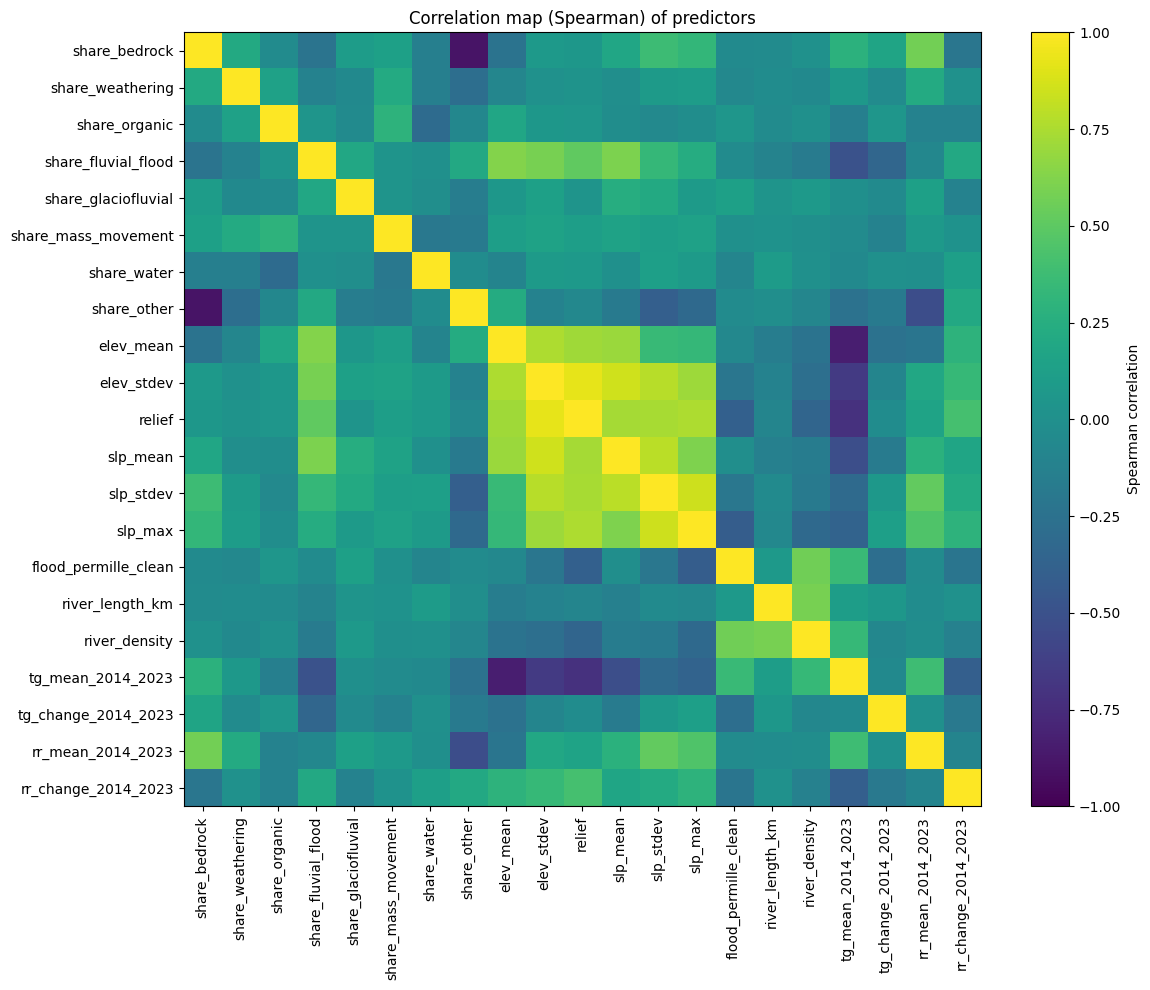

In [85]:
# Correlation map
plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Spearman correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation map (Spearman) of predictors")
plt.tight_layout()
plt.show()

In [86]:
cols_to_drop = ["slp_stdev", "elev_stdev"]
df_merged = df_merged.drop(columns=cols_to_drop, errors="ignore")

Highly correlated predictors were removed before logistic regression (slp_stdev, elev_stdev) to reduce multicollinearity

# Model training

## Splitting

In [87]:

target = "Yi_shallow"
id_cols = ["kommunenummer", "kommunenavn"]

# Full numeric feature set
X_all = df_merged.drop(columns=id_cols + [target], errors="ignore").select_dtypes(include="number")
y = df_merged[target]

# Remove flood feature for landslide-only model
X_noflood = X_all.drop(columns=["flood_permille_clean"], errors="ignore")

print("Features with flood:", X_all.columns.tolist())
print("Features without flood:", X_noflood.columns.tolist())
print("Number of features without flood:", X_noflood.shape[1])

# Same split logic as before
X_train_nf, X_test_nf, y_train_nf, y_test_nf = train_test_split(
    X_noflood, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train_nf, X_val_nf, y_train_nf, y_val_nf = train_test_split(
    X_train_nf, y_train_nf,
    test_size=0.25,   # gives final 60:20:20 split
    stratify=y_train_nf,
    random_state=42
)

print("Train shape:", X_train_nf.shape)
print("Validation shape:", X_val_nf.shape)
print("Test shape:", X_test_nf.shape)

Features with flood: ['share_bedrock', 'share_weathering', 'share_organic', 'share_fluvial_flood', 'share_glaciofluvial', 'share_mass_movement', 'share_water', 'share_other', 'elev_mean', 'relief', 'slp_mean', 'slp_max', 'flood_permille_clean', 'river_length_km', 'river_density', 'tg_mean_2014_2023', 'tg_change_2014_2023', 'rr_mean_2014_2023', 'rr_change_2014_2023']
Features without flood: ['share_bedrock', 'share_weathering', 'share_organic', 'share_fluvial_flood', 'share_glaciofluvial', 'share_mass_movement', 'share_water', 'share_other', 'elev_mean', 'relief', 'slp_mean', 'slp_max', 'river_length_km', 'river_density', 'tg_mean_2014_2023', 'tg_change_2014_2023', 'rr_mean_2014_2023', 'rr_change_2014_2023']
Number of features without flood: 18
Train shape: (213, 18)
Validation shape: (71, 18)
Test shape: (71, 18)


## Logistic regression

In [88]:
# Logistic regression on no-flood features
log_model_nf = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42))
])

log_model_nf.fit(X_train_nf, y_train_nf)

train_proba_log_nf = log_model_nf.predict_proba(X_train_nf)[:, 1]
val_proba_log_nf   = log_model_nf.predict_proba(X_val_nf)[:, 1]
test_proba_log_nf  = log_model_nf.predict_proba(X_test_nf)[:, 1]

def evaluate_probs(y_true, y_proba, name="set"):
    roc = roc_auc_score(y_true, y_proba)
    pr = average_precision_score(y_true, y_proba)
    brier = brier_score_loss(y_true, y_proba)
    print(f"{name} ROC-AUC: {roc:.3f}")
    print(f"{name} PR-AUC:  {pr:.3f}")
    print(f"{name} Brier:   {brier:.3f}")
    print()
    return {"Split": name, "ROC-AUC": roc, "PR-AUC": pr, "Brier": brier}

log_nf_results = []
log_nf_results.append(evaluate_probs(y_train_nf, train_proba_log_nf, "Train"))
log_nf_results.append(evaluate_probs(y_val_nf,   val_proba_log_nf,   "Validation"))
log_nf_results.append(evaluate_probs(y_test_nf,  test_proba_log_nf,  "Test"))

Train ROC-AUC: 0.937
Train PR-AUC:  0.993
Train Brier:   0.052

Validation ROC-AUC: 0.877
Validation PR-AUC:  0.985
Validation Brier:   0.064

Test ROC-AUC: 0.737
Test PR-AUC:  0.963
Test Brier:   0.094



In [89]:
log_model_nf.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('logreg', LogisticRegression(max_iter=1000, random_state=42))],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'logreg': LogisticRegression(max_iter=1000, random_state=42),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'logreg__C': 1.0,
 'logreg__class_weight': None,
 'logreg__dual': False,
 'logreg__fit_intercept': True,
 'logreg__intercept_scaling': 1,
 'logreg__l1_ratio': None,
 'logreg__max_iter': 1000,
 'logreg__multi_class': 'deprecated',
 'logreg__n_jobs': None,
 'logreg__penalty': 'l2',
 'logreg__random_state': 42,
 'logreg__solver': 'lbfgs',
 'logreg__tol': 0.0001,
 'logreg__verbose': 0,
 'logreg__warm_start': False}

Train ROC-AUC: 0.937
Train PR-AUC:  0.993
Train Brier:   0.052

Validation ROC-AUC: 0.877
Validation PR-AUC:  0.985
Validation Brier:   0.064

Test ROC-AUC: 0.737
Test PR-AUC:  0.963
Test Brier:   0.094

Logistic regression was used as a transparent probabilistic baseline because the target is binary and the study focuses on estimating municipal probabilities rather than only class labels. Its simplicity and interpretability make it a useful benchmark against more flexible tree-based models

SMOTE was not applied because the target was not a rare-event problem and probability calibration was prioritised.

ROC-AUC was used to assess class discrimination, PR-AUC to complement evaluation of the positive class, and the Brier score to assess the quality of predicted probabilities. Because the study aims to map municipal landslide probabilities rather than only assign binary classes, calibration-oriented metrics were prioritised over accuracy

The logistic regression baseline showed good apparent discrimination on the training and validation splits, but performance decreased on the held-out test set (ROC-AUC 0.725; Brier score 0.099), indicating more limited generalisation. Precision–recall AUC remained high across splits, but this metric should be interpreted cautiously because the positive class was highly prevalent. Therefore, probability quality and calibration were prioritised over accuracy-like metrics when selecting the final model.

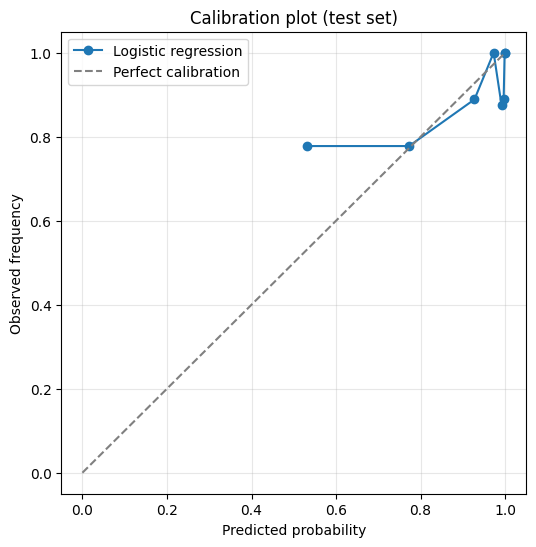

In [90]:
# Calibration curve for test set
prob_true, prob_pred = calibration_curve(y_test_nf, test_proba_log_nf, n_bins=8, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Logistic regression")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration plot (test set)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Base tree model

In [91]:
# Base model
tree_base_nf = HistGradientBoostingClassifier(
    max_depth=5,
    learning_rate=0.01,
    max_iter=200,
    min_samples_leaf=10,
    l2_regularization=1,
    random_state=42
)

# Calibrated model
tree_model_nf = CalibratedClassifierCV(tree_base_nf, method="sigmoid", cv=5)
tree_model_nf.fit(X_train_nf, y_train_nf)

# Predict probabilities
train_proba_nf = tree_model_nf.predict_proba(X_train_nf)[:, 1]
val_proba_nf   = tree_model_nf.predict_proba(X_val_nf)[:, 1]
test_proba_nf  = tree_model_nf.predict_proba(X_test_nf)[:, 1]

def evaluate_probs(y_true, y_proba, name="set"):
    roc = roc_auc_score(y_true, y_proba)
    pr = average_precision_score(y_true, y_proba)
    brier = brier_score_loss(y_true, y_proba)
    print(f"{name} ROC-AUC: {roc:.3f}")
    print(f"{name} PR-AUC:  {pr:.3f}")
    print(f"{name} Brier:   {brier:.3f}")
    print()
    return {"Split": name, "ROC-AUC": roc, "PR-AUC": pr, "Brier": brier}

results_nf = []
results_nf.append(evaluate_probs(y_train_nf, train_proba_nf, "Train"))
results_nf.append(evaluate_probs(y_val_nf,   val_proba_nf,   "Validation"))
results_nf.append(evaluate_probs(y_test_nf,  test_proba_nf,  "Test"))

Train ROC-AUC: 0.991
Train PR-AUC:  0.999
Train Brier:   0.038

Validation ROC-AUC: 0.964
Validation PR-AUC:  0.996
Validation Brier:   0.059

Test ROC-AUC: 0.821
Test PR-AUC:  0.976
Test Brier:   0.076



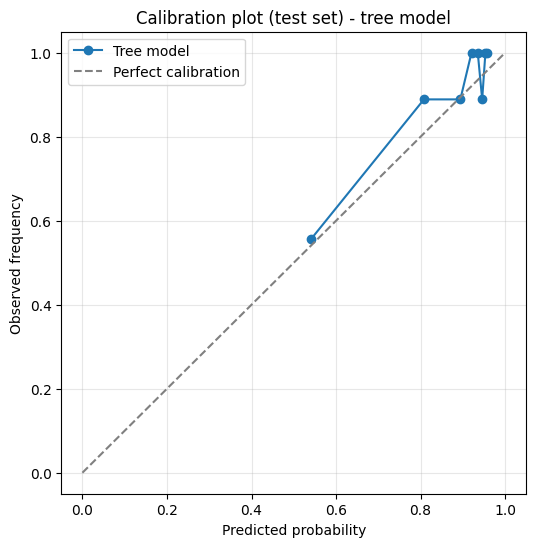

In [92]:
prob_true_tree, prob_pred_tree = calibration_curve(
    y_test_nf, test_proba_nf, n_bins=8, strategy="quantile"
)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred_tree, prob_true_tree, marker="o", label="Tree model")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration plot (test set) - tree model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The tree-based model outperformed the logistic regression baseline on the held-out test set, improving ROC-AUC from 0.725 to 0.788 and reducing the Brier score from 0.099 to 0.079. This suggests that nonlinear relationships among terrain, deposit, hydrological and climate predictors were important for municipal landslide probability estimation. Although near-perfect training performance indicated some overfitting, the calibrated tree model still generalised better than the linear baseline.

In [97]:
finaltree_base_nf = CalibratedClassifierCV(tree_base_nf, method="sigmoid", cv=5)
finaltree_base_nf.fit(X_noflood, y)

# Full-dataset probabilities
df_probs_flood = df_merged[id_cols + ["flood_permille_clean"]].copy()
df_probs_flood["landslide_prob_noflood"] = finaltree_base_nf.predict_proba(X_noflood)[:, 1]

print(df_probs_flood.head())

  kommunenummer  kommunenavn  flood_permille_clean  landslide_prob_noflood
0          3419        Våler                 0.092                   0.952
1          3326     Hemsedal                 0.055                   0.968
2          4622         Kvam                 0.061                   0.967
3          5054  Indre Fosen                 0.026                   0.968
4          4617   Kvinnherad                 0.026                   0.968


In [122]:
# Load municipality polygons
municipalities_gdf = gpd.read_file("drive/MyDrive/Colab Notebooks/Bachelor/municipalities_master.gpkg")
municipalities_gdf["kommunenummer"] = municipalities_gdf["kommunenummer"].astype(str).str.strip().str.zfill(4)

# Keep only needed columns
municipalities_gdf = municipalities_gdf[["kommunenummer", "kommunenavn", "geometry"]].copy()

# Ensure consistent municipality id format
df_probs_flood["kommunenummer"] = df_probs_flood["kommunenummer"].astype(str).str.strip().str.zfill(4)

# Merge probabilities with municipality geometry
gdf_plot_noflood = municipalities_gdf.merge(
    df_probs_flood[["kommunenummer", "landslide_prob_noflood"]],
    on="kommunenummer",
    how="left"
)

# Mark excluded municipalities as missing
exclude_ids = ["1856", "1144"]  # Røst, Kvitsøy
gdf_plot_noflood.loc[
    gdf_plot_noflood["kommunenummer"].isin(exclude_ids),
    "landslide_prob_noflood"
] = np.nan

# Optional scale bar flag
HAS_SCALEBAR = True

print("GeoDataFrame gdf_plot_noflood created successfully.")
print(gdf_plot_noflood.head())
print("Number of municipalities:", len(gdf_plot_noflood))

GeoDataFrame gdf_plot_noflood created successfully.
  kommunenummer  kommunenavn  \
0          3419        Våler   
1          3326     Hemsedal   
2          4622         Kvam   
3          5054  Indre Fosen   
4          4617   Kvinnherad   

                                            geometry  landslide_prob_noflood  
0  MULTIPOLYGON (((341137.98 6744380.63, 341141.5...                   0.952  
1  MULTIPOLYGON (((160121.15 6755204.84, 160138.8...                   0.968  
2  MULTIPOLYGON (((151.2 6728128.35, 165.86 67277...                   0.967  
3  MULTIPOLYGON (((241758.34 7067700.56, 241711.9...                   0.968  
4  MULTIPOLYGON (((-19655.36 6675164.92, -21061.9...                   0.968  
Number of municipalities: 357


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: Non-conformant content for record 1 in column oppdateringsdato, 2024-05-10T13:00:48+02:00, successfully parsed
  return ogr_read(


## Map

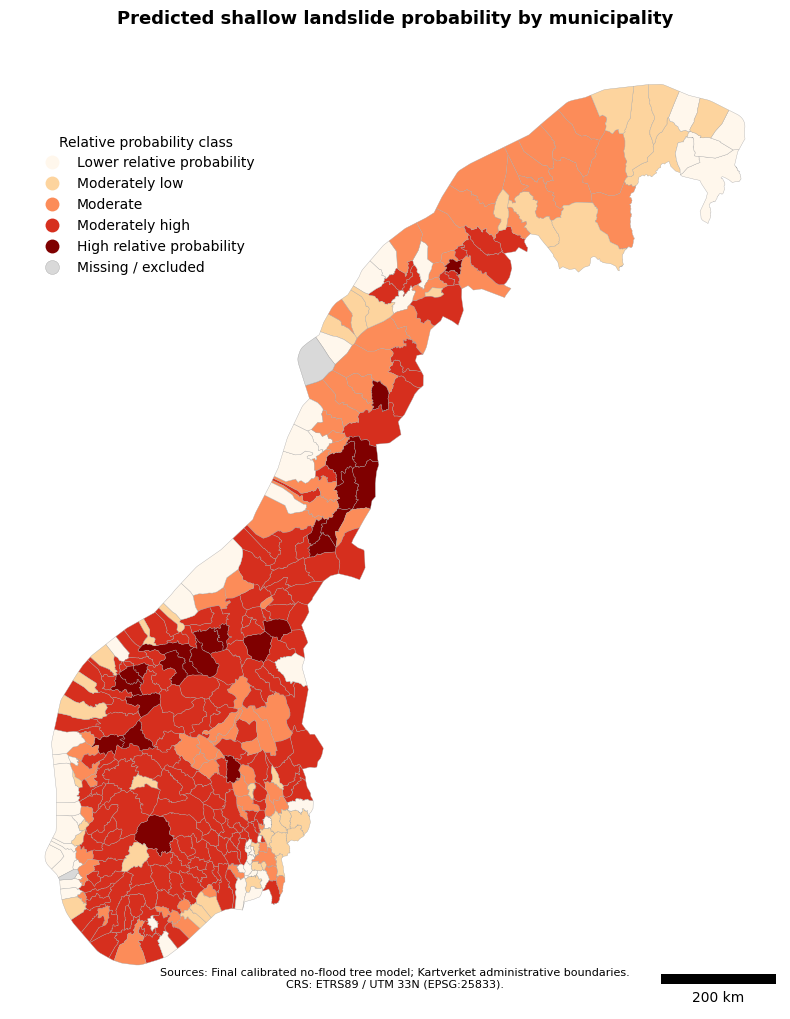

In [123]:
fig, ax = plt.subplots(figsize=(8, 12), facecolor="white")
ax.set_facecolor("white")

gdf_plot_noflood.plot(
    column="landslide_prob_noflood",
    cmap="OrRd",
    scheme="UserDefined",
    classification_kwds={"bins": [0.80, 0.90, 0.95, 0.97]},
    linewidth=0.25,
    edgecolor="0.65",
    legend=True,
    ax=ax,
    missing_kwds={
        "color": "#d9d9d9",
        "edgecolor": "0.6",
        "label": "Missing / excluded"
    },
    legend_kwds={
        "title": "Relative probability class",
        "loc": "center left",
        "bbox_to_anchor": (0.02, 0.83),
        "frameon": False
    }
)

leg = ax.get_legend()
if leg is not None:
    new_labels = [
        "Lower relative probability",
        "Moderately low",
        "Moderate",
        "Moderately high",
        "High relative probability",
        "Missing / excluded"
    ]
    for txt, new_lab in zip(leg.get_texts(), new_labels):
        txt.set_text(new_lab)

# Title + subtitle style
ax.set_title(
    "Predicted shallow landslide probability by municipality",
    fontsize=13,
    fontweight="bold",
    pad=12
)


# Optional scale bar
if HAS_SCALEBAR:
    # EPSG:25833 uses meters
    scalebar = ScaleBar(
        dx=1,
        units="m",
        dimension="si-length",
        location="lower right",
        box_alpha=0,
        color="black",
        length_fraction=0.2
    )
    ax.add_artist(scalebar)

# Source note
ax.text(
    0.5, 0.02,
    "Sources: Final calibrated no-flood tree model; Kartverket administrative boundaries.\n"
    "CRS: ETRS89 / UTM 33N (EPSG:25833).",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=8
)

ax.set_axis_off()
plt.tight_layout()

output_dir = "images"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(output_dir, "landslide_probability_noflood_map_clean.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

In [124]:
print(gdf_plot_noflood["landslide_prob_noflood"].describe())

count   355.000
mean      0.894
std       0.141
min       0.327
25%       0.904
50%       0.955
75%       0.968
max       0.970
Name: landslide_prob_noflood, dtype: float64


# SHAP

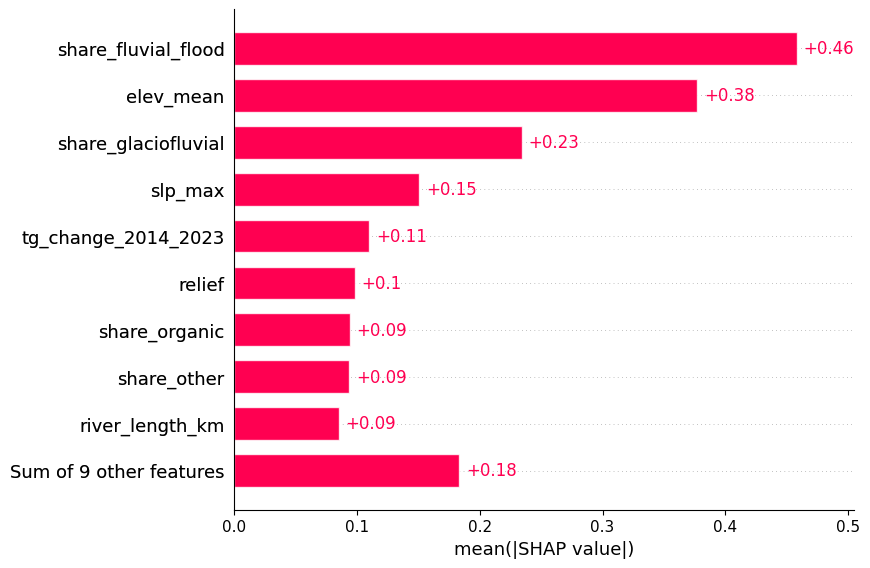

In [106]:
# Fit base model on training data
tree_base_nf.fit(X_train_nf, y_train_nf)

# SHAP explainer for tree model
explainer = shap.Explainer(tree_base_nf, X_train_nf)

# Compute SHAP values on test set (or validation set if you prefer)
shap_values = explainer(X_test_nf, check_additivity=False)

# 1) Global importance plot
shap.plots.bar(shap_values, max_display=10)

SHAP bar plot shows the average absolute contribution of each feature to the tree-based landslide model predictions. Higher mean(|SHAP|) values indicate that a feature has a stronger overall influence on the predicted municipal landslide probability. Global SHAP importance indicates that share_fluvial_flood was the most influential predictor in the final tree-based landslide model, followed by elev_mean, share_glaciofluvial, and slp_max. These features had the largest average effect on predicted landslide probability across municipalities. Additional important contributors included tg_change_2014_2023, relief, share_organic, share_other, and river_length_km. The combined contribution of the remaining features was also substantial.

The SHAP ranking appears broadly plausible, as terrain-related predictors, deposit composition, and selected hydrological and climate-related variables are expected to influence landslide susceptibility. However, SHAP importance should be interpreted as model-based association rather than direct causal evidence. In particular, the high importance of fluvial/flood-related deposits may reflect broader hydrological and geomorphological context rather than a simple one-to-one causal effect.

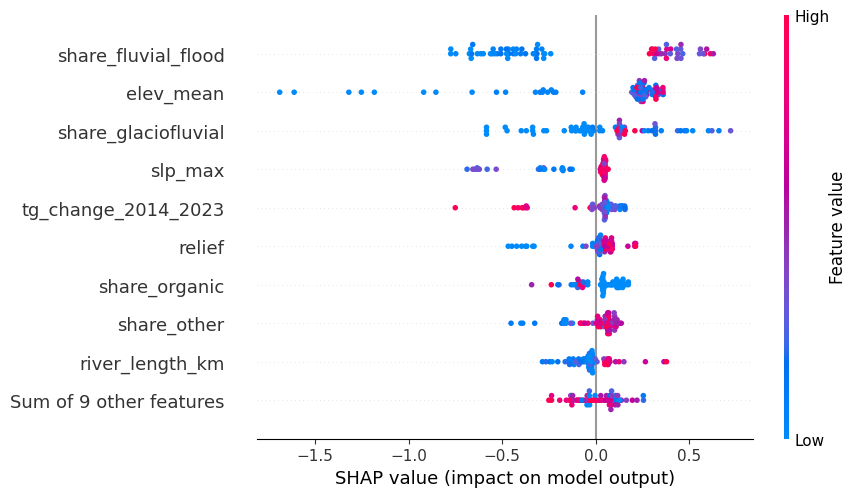

In [107]:
# Summary plot
shap.plots.beeswarm(shap_values, max_display=10)

SHAP beeswarm plot provides additional insight into the direction and heterogeneity of predictor effects. Higher values of share_fluvial_flood and slp_max were generally associated with higher predicted landslide probability, whereas lower values of these variables more often reduced the model output. Higher values of relief also tended to push predictions upward, although with greater variability across municipalities. In contrast, predictors such as elev_mean, share_glaciofluvial, and tg_change_2014_2023 showed more heterogeneous patterns, suggesting nonlinear or context-dependent effects. Lower values of elev_mean were often associated with negative SHAP contributions, while higher values tended to be closer to zero or moderately positive.

The remaining predictors, including share_organic, share_other, and river_length_km, had smaller but still visible contributions, with both positive and negative effects depending on municipality context. Overall, the beeswarm plot suggests that the final model captured a combination of directional and nonlinear relationships rather than a single uniform effect for all predictors.

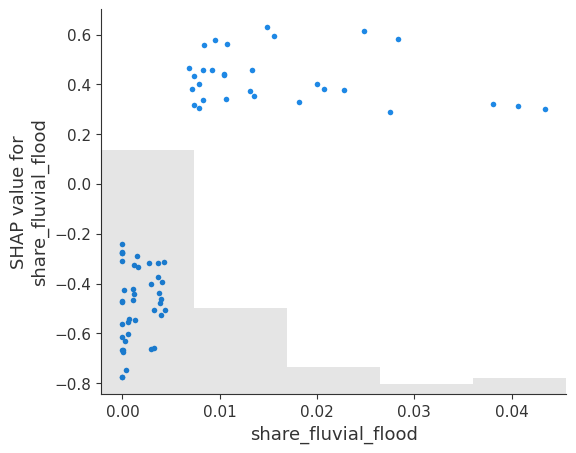

In [108]:
shap.plots.scatter(shap_values[:, "share_fluvial_flood"])

Municipality features:


,share_bedrock,share_weathering,share_organic,share_fluvial_flood,share_glaciofluvial,share_mass_movement,share_water,share_other,elev_mean,relief,slp_mean,slp_max,river_length_km,river_density,tg_mean_2014_2023,tg_change_2014_2023,rr_mean_2014_2023,rr_change_2014_2023
81,0.524,0.000,0.000,0.000,0.000,0.000,0.021,0.455,3.846,802.600,0.469,67.800,0.120,0.000,6.450,-1.240,1179.120,94.410


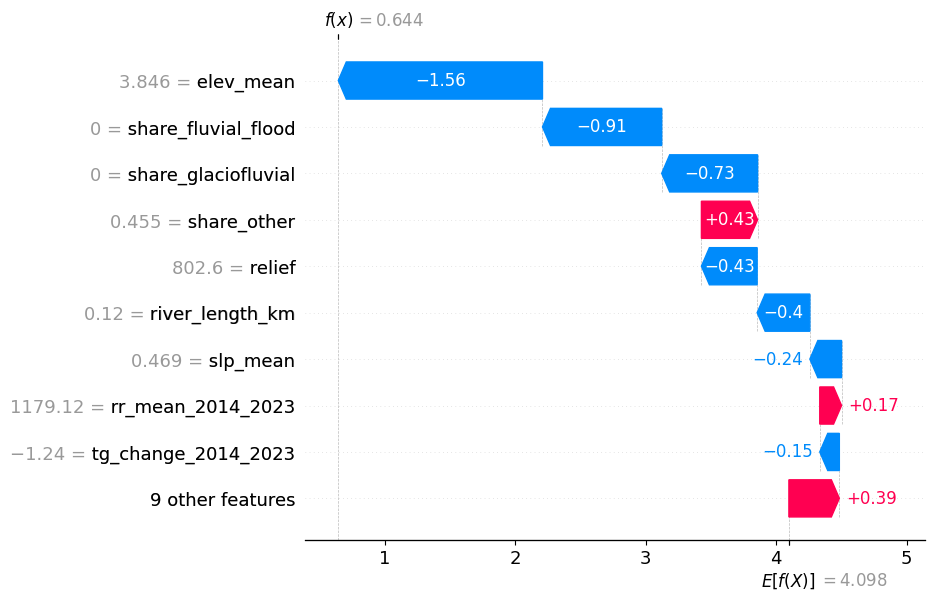

In [109]:
# Base tree model used inside calibration
base_model = HistGradientBoostingClassifier(
    max_depth=3,
    learning_rate=0.05,
    max_iter=100,
    random_state=42
)

# Fit base model on training data
base_model.fit(X_train_nf, y_train_nf)

# SHAP explainer for tree model
explainer = shap.Explainer(base_model, X_train_nf)

# Compute SHAP values on test set (or validation set if you prefer)
shap_values = explainer(X_test_nf, check_additivity=False)

# Pick one municipality from the test set
row_id = 0

print("Municipality features:")
display(X_test_nf.iloc[[row_id]])

# Waterfall plot for one prediction
shap.plots.waterfall(shap_values[row_id], max_display=10)

 The SHAP waterfall plot starts from the model’s average output (E[f(X)]) and then shows how each feature moves the prediction up or down for the selected municipality until the final model output (f(x)) is reached.

For Vega, the model output was pulled downward relative to the baseline mainly by low elev_mean, zero share_fluvial_flood, zero share_glaciofluvial, relatively high relief, low river_length_km, low slp_mean, and negative tg_change_2014_2023. Positive contributions came from share_other, rr_mean_2014_2023, and the combined effect of several smaller features, but these were not sufficient to offset the stronger negative contributions. Overall, the local explanation suggests that Vega received a lower predicted landslide probability than the model baseline because several of its observed predictor values pushed the model output downward.

In [110]:
# Recover municipality names for X_test rows
test_meta = df_merged.loc[X_test_nf.index, ["kommunenummer", "kommunenavn"]].copy()
test_meta.iloc[row_id]

,81
kommunenummer,1815
kommunenavn,Vega


SHAP was used to explain both global feature importance and municipality-level predictions for the final tree-based model. SHAP values indicate which predictors contributed most to the model output; they should be interpreted as model-based associations rather than causal effects.

# Multi-hazard index

In [127]:
df_mhi = df_probs_flood.copy()

def minmax(series):
    return (series - series.min()) / (series.max() - series.min())

# Min-max normalize both components
df_mhi["ls_prob_mm"] = minmax(df_mhi["landslide_prob_noflood"])
df_mhi["flood_mm"] = minmax(df_mhi["flood_permille_clean"])

# Combined relative index
df_mhi["mhi"] = (df_mhi["ls_prob_mm"] + df_mhi["flood_mm"]) / 2

# Make sure municipality id format matches
municipalities_gdf["kommunenummer"] = municipalities_gdf["kommunenummer"].astype(str).str.strip().str.zfill(4)
df_mhi["kommunenummer"] = df_mhi["kommunenummer"].astype(str).str.strip().str.zfill(4)

# Keep only needed columns in geometry
municipalities_plot = municipalities_gdf[["kommunenummer", "kommunenavn", "geometry"]].copy()

# Merge
gdf_mhi = municipalities_plot.merge(
    df_mhi[["kommunenummer", "mhi"]],
    on="kommunenummer",
    how="left"
)

# Mark excluded municipalities as missing
exclude_ids = ["1856", "1144"]   # Røst, Kvitsøy
gdf_mhi.loc[gdf_mhi["kommunenummer"].isin(exclude_ids), "mhi"] = np.nan

print("GeoDataFrame gdf_mhi created successfully.")
print(gdf_mhi.head())
print("Number of municipalities on map:", len(gdf_mhi))

GeoDataFrame gdf_mhi created successfully.
  kommunenummer  kommunenavn  \
0          3419        Våler   
1          3326     Hemsedal   
2          4622         Kvam   
3          5054  Indre Fosen   
4          4617   Kvinnherad   

                                            geometry   mhi  
0  MULTIPOLYGON (((341137.98 6744380.63, 341141.5... 0.527  
1  MULTIPOLYGON (((160121.15 6755204.84, 160138.8... 0.523  
2  MULTIPOLYGON (((151.2 6728128.35, 165.86 67277... 0.525  
3  MULTIPOLYGON (((241758.34 7067700.56, 241711.9... 0.510  
4  MULTIPOLYGON (((-19655.36 6675164.92, -21061.9... 0.510  
Number of municipalities on map: 357


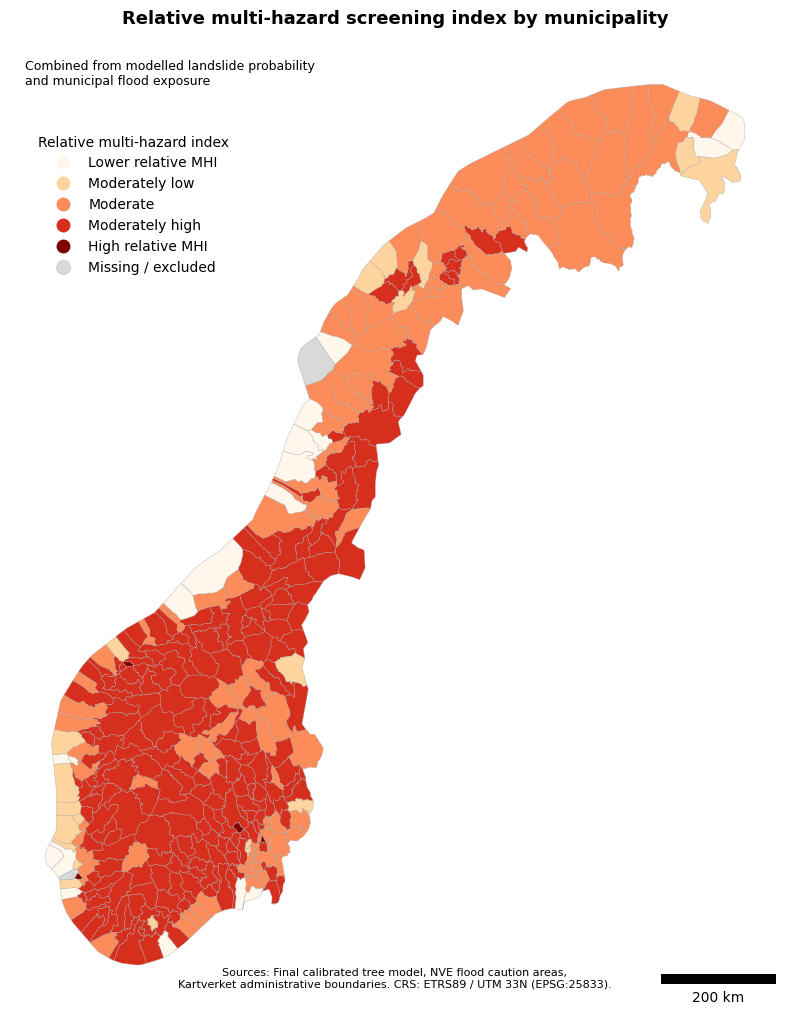

In [128]:
fig, ax = plt.subplots(figsize=(8, 12), facecolor="white")
ax.set_facecolor("white")

gdf_mhi.plot(
    column="mhi",
    cmap="OrRd",
    scheme="UserDefined",
    classification_kwds={"bins": [0.20, 0.35, 0.50, 0.65]},
    linewidth=0.25,
    edgecolor="0.65",
    legend=True,
    ax=ax,
    missing_kwds={
        "color": "#d9d9d9",
        "edgecolor": "0.6",
        "label": "Missing / excluded"
    },
    legend_kwds={
        "title": "Relative multi-hazard index",
        "loc": "center left",
        "bbox_to_anchor": (0.02, 0.83),
        "frameon": False
    }
)

leg = ax.get_legend()
if leg is not None:
    new_labels = [
        "Lower relative MHI",
        "Moderately low",
        "Moderate",
        "Moderately high",
        "High relative MHI",
        "Missing / excluded"
    ]
    for txt, new_lab in zip(leg.get_texts(), new_labels):
        txt.set_text(new_lab)

# Title
ax.set_title(
    "Relative multi-hazard screening index by municipality",
    fontsize=13,
    fontweight="bold",
    pad=12
)

# Note under legend area
ax.text(
    0.02, 0.98,
    "Combined from modelled landslide probability\n"
    "and municipal flood exposure\n",

    transform=ax.transAxes,
    fontsize=9,
    va="top"
)

# Optional scale bar
if HAS_SCALEBAR:
    # EPSG:25833 uses meters
    scalebar = ScaleBar(
        dx=1,
        units="m",
        dimension="si-length",
        location="lower right",
        box_alpha=0,
        color="black",
        length_fraction=0.2
    )
    ax.add_artist(scalebar)

# Source note
ax.text(
    0.5, 0.02,
    "Sources: Final calibrated tree model, NVE flood caution areas,\n"
    "Kartverket administrative boundaries. CRS: ETRS89 / UTM 33N (EPSG:25833).",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=8
)

ax.set_axis_off()
plt.tight_layout()

output_dir = "images"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(
    os.path.join(output_dir, "mhi_model_based_map_clean.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

Municipal landslide probabilities from the final tree-based model were min–max normalised and combined with a normalised flood exposure indicator (flood_permille_clean) to produce a simple multi-hazard index. The index is intended as a relative screening measure rather than a fully probabilistic estimate of joint hazard.

The index behaved as intended: municipalities ranked highest when both components were elevated, not only when one hazard dominated

In [130]:
top_mhi = (
    df_mhi.sort_values("mhi", ascending=False)
    .loc[:, ["kommunenavn", "landslide_prob_noflood", "flood_permille_clean", "mhi"]]
    .head(10)
    .reset_index(drop=True)
)

top_mhi.index = top_mhi.index + 1
top_mhi = top_mhi.reset_index().rename(columns={
    "index": "Rank",
    "kommunenavn": "Municipality",
    "landslide_prob_noflood": "Landslide probability",
    "flood_permille_clean": "Flood exposure (‰)",
    "mhi": "Relative MHI"
})

top_mhi["Landslide probability"] = top_mhi["Landslide probability"].round(3)
top_mhi["Flood exposure (‰)"] = top_mhi["Flood exposure (‰)"].round(3)
top_mhi["Relative MHI"] = top_mhi["Relative MHI"].round(3)

print(top_mhi)

   Rank Municipality  Landslide probability  Flood exposure (‰)  Relative MHI
0     1     Rælingen                  0.956               0.924         0.902
1     2         Hole                  0.953               0.687         0.794
2     3    Randaberg                  0.534               1.119         0.661
3     4         Sula                  0.965               0.361         0.657
4     5    Bjerkreim                  0.968               0.329         0.645
5     6       Hareid                  0.967               0.324         0.642
6     7     Gjerdrum                  0.946               0.253         0.594
7     8     Jevnaker                  0.905               0.300         0.584
8     9      Enebakk                  0.943               0.229         0.581
9    10       Hurdal                  0.961               0.193         0.579


In [131]:
latex_table = top_mhi.to_latex(index=False, escape=False)
print(latex_table)

\begin{tabular}{rlrrr}
\toprule
Rank & Municipality & Landslide probability & Flood exposure (‰) & Relative MHI \\
\midrule
1 & Rælingen & 0.956000 & 0.924000 & 0.902000 \\
2 & Hole & 0.953000 & 0.687000 & 0.794000 \\
3 & Randaberg & 0.534000 & 1.119000 & 0.661000 \\
4 & Sula & 0.965000 & 0.361000 & 0.657000 \\
5 & Bjerkreim & 0.968000 & 0.329000 & 0.645000 \\
6 & Hareid & 0.967000 & 0.324000 & 0.642000 \\
7 & Gjerdrum & 0.946000 & 0.253000 & 0.594000 \\
8 & Jevnaker & 0.905000 & 0.300000 & 0.584000 \\
9 & Enebakk & 0.943000 & 0.229000 & 0.581000 \\
10 & Hurdal & 0.961000 & 0.193000 & 0.579000 \\
\bottomrule
\end{tabular}



In [132]:
print("Top 10 by landslide probability")
display(df_mhi.sort_values("landslide_prob_noflood", ascending=False)[
    ["kommunenummer","kommunenavn","landslide_prob_noflood","flood_permille_clean","mhi"]
].head(10))

print("Top 10 by flood exposure")
display(df_mhi.sort_values("flood_permille_clean", ascending=False)[
    ["kommunenummer","kommunenavn","landslide_prob_noflood","flood_permille_clean","mhi"]
].head(10))

Top 10 by landslide probability


,kommunenummer,kommunenavn,landslide_prob_noflood,flood_permille_clean,mhi
157,5046,Høylandet,0.970,0.058,0.526
22,1824,Vefsn,0.970,0.018,0.508
29,4651,Stryn,0.970,0.031,0.514
16,4638,Høyanger,0.970,0.035,0.516
272,1577,Volda,0.970,0.041,0.518
243,5045,Grong,0.970,0.031,0.514
23,1825,Grane,0.970,0.023,0.510
38,1506,Molde,0.970,0.021,0.509
84,5522,Salangen,0.970,0.091,0.541
116,1832,Hemnes,0.970,0.033,0.515


Top 10 by flood exposure


,kommunenummer,kommunenavn,landslide_prob_noflood,flood_permille_clean,mhi
20,1127,Randaberg,0.534,1.119,0.661
45,3224,Rælingen,0.956,0.924,0.902
347,3310,Hole,0.953,0.687,0.794
273,3112,Råde,0.647,0.559,0.498
46,3222,Lørenskog,0.656,0.455,0.459
185,3116,Skiptvet,0.805,0.364,0.535
155,1531,Sula,0.965,0.361,0.657
285,1114,Bjerkreim,0.968,0.329,0.645
183,1517,Hareid,0.967,0.324,0.642
130,3236,Jevnaker,0.905,0.300,0.584


# LLM

In [133]:
# 1. API key
with open("creds.json", "r", encoding="utf-8") as file:
    creds = json.load(file)

os.environ["OPENAI_API_KEY"] = creds["OPENAI_API_KEY"]
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

# 2. CONFIG
MODEL_NAME = "gpt-5.4-mini"
TEST_MODE = False

TEST_MUNICIPALITIES = [
    "Vega",
    "Nord-Fron",
    "Randaberg",
    "Fjaler",
    "Kvam"
]

TOP_N_POS = 3
TOP_N_NEG = 3
SLEEP_BETWEEN_CALLS = 0.4

OUTPUT_CSV = "municipality_llm_explanations.csv"
OUTPUT_PARQUET = "municipality_llm_explanations.parquet"
OUTPUT_FULL_CSV = "df_mhi_with_llm.csv"
OUTPUT_FULL_PARQUET = "df_mhi_with_llm.parquet"

FEATURE_LABELS = {
    "elev_mean": "mean elevation",
    "elev_stdev": "elevation variability",
    "relief": "elevation range",
    "slp_mean": "mean slopey",
    "slp_stdev": "slope variability",
    "slp_max": "maximum slope",
    "river_length_km": "total river length",
    "river_density": "river length per unit area",
    "flood_permille_clean": "share of municipal area overlapping flood caution zones",
    "share_fluvial_flood": "fluvial or flood-related deposits",
    "share_glaciofluvial": "glaciofluvial deposits",
    "share_mass_movement": "mass-movement-related deposits",
    "share_organic": "organic deposits",
    "share_other": "other mapped surface deposit types",
    "share_bedrock": "exposed bedrock or very thin cover",
    "share_weathering": "weathered material deposits",
    "share_water": "mapped water-covered area",
    "tg_mean_2014_2023": "mean temperature over 2014–2023",
    "tg_change_2014_2023": "temperature change between 2014 and 2023",
    "rr_mean_2014_2023": "mean precipitation over 2014–2023",
    "rr_change_2014_2023": "precipitation change between 2014 and 2023"
}


# 3. ASSUMPTIONS ABOUT EXISTING OBJECTS

required_objects = ["df_merged", "X_noflood", "y", "df_mhi", "id_cols"]
for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(f"Required object '{obj_name}' is missing. Run previous cells first.")

# sanity checks
needed_cols_df_mhi = ["kommunenummer", "kommunenavn", "landslide_prob_noflood", "flood_permille_clean", "mhi"]
for c in needed_cols_df_mhi:
    if c not in df_mhi.columns:
        raise ValueError(f"Column '{c}' is missing in df_mhi")

# standardize kommune id
df_merged["kommunenummer"] = df_merged["kommunenummer"].astype(str).str.strip().str.zfill(4)
df_mhi["kommunenummer"] = df_mhi["kommunenummer"].astype(str).str.strip().str.zfill(4)

# 4. FIT BASE TREE MODEL FOR SHAP ON FULL DATA

base_model_for_shap = HistGradientBoostingClassifier(
    max_depth=5,
    learning_rate=0.01,
    max_iter=200,
    min_samples_leaf=10,
    l2_regularization=1,
    random_state=42
)

base_model_for_shap.fit(X_noflood, y)

# SHAP explainer
explainer = shap.Explainer(base_model_for_shap, X_noflood)

# Compute SHAP for all retained municipalities
shap_values_all = explainer(X_noflood, check_additivity=False)

print("SHAP values computed for all municipalities.")
print("Shape:", shap_values_all.values.shape)

# 5. BUILD LOCAL SHAP TEXT FOR EACH MUNICIPALITY

feature_names = list(X_noflood.columns)
shap_matrix = shap_values_all.values  # shape: (n_rows, n_features)

def get_top_shap_features(shap_row, feature_names, top_n_pos=3, top_n_neg=3):
    shap_row = np.array(shap_row)

    # Positive contributors
    pos_idx = np.where(shap_row > 0)[0]
    pos_sorted = pos_idx[np.argsort(shap_row[pos_idx])[::-1]] if len(pos_idx) > 0 else np.array([], dtype=int)

    # Negative contributors
    neg_idx = np.where(shap_row < 0)[0]
    neg_sorted = neg_idx[np.argsort(shap_row[neg_idx])] if len(neg_idx) > 0 else np.array([], dtype=int)

    top_pos = []
    for i in pos_sorted[:top_n_pos]:
        label = FEATURE_LABELS.get(feature_names[i], feature_names[i])
        top_pos.append(label)


    top_neg = []
    for i in neg_sorted[:top_n_neg]:
        label = FEATURE_LABELS.get(feature_names[i], feature_names[i])
        top_neg.append(label)

    return top_pos, top_neg

records_shap = []

for row_idx in range(len(X_noflood)):
    top_pos, top_neg = get_top_shap_features(
        shap_row=shap_matrix[row_idx],
        feature_names=feature_names,
        top_n_pos=TOP_N_POS,
        top_n_neg=TOP_N_NEG
    )

    records_shap.append({
        "row_index": X_noflood.index[row_idx],
        "top_positive_shap": ", ".join(top_pos) if top_pos else "Not available",
        "top_negative_shap": ", ".join(top_neg) if top_neg else "Not available"
    })

df_shap_text = pd.DataFrame(records_shap)

# Merge row index -> municipality metadata
meta_cols = ["kommunenummer", "kommunenavn"]
df_meta = df_merged.loc[X_noflood.index, meta_cols].copy()
df_meta["row_index"] = df_meta.index

df_shap_text = df_shap_text.merge(df_meta, on="row_index", how="left")
df_shap_text["kommunenummer"] = df_shap_text["kommunenummer"].astype(str).str.strip().str.zfill(4)

print(df_shap_text.head())


# 6. BUILD FINAL LLM INPUT TABL

df_llm = df_mhi.merge(
    df_shap_text[["kommunenummer", "top_positive_shap", "top_negative_shap"]],
    on="kommunenummer",
    how="left"
).copy()

# Fill missing SHAP text if any
df_llm["top_positive_shap"] = df_llm["top_positive_shap"].fillna("Not available")
df_llm["top_negative_shap"] = df_llm["top_negative_shap"].fillna("Not available")

#  test mode
if TEST_MODE:
    df_run = df_llm[df_llm["kommunenavn"].isin(TEST_MUNICIPALITIES)].copy()
    print(f"TEST_MODE=True -> running on {len(df_run)} municipalities")
else:
    df_run = df_llm.copy()
    print(f"TEST_MODE=False -> running on all {len(df_run)} municipalities")

if df_run.empty:
    raise ValueError("No municipalities selected. Check TEST_MUNICIPALITIES names.")


# 7. PROMPT LOGIC

INSTRUCTIONS = """
You are assisting a Norway municipal multi-hazard dashboard.

Your task is to convert already computed structured outputs into a short, public-facing explanation.

Rules:
- Use only the provided values and labels.
- Do not add outside facts.
- Do not mention future trends.
- Do not claim causality.
- Do not say that the model proves anything.
- Treat model contributors as model-based signals, not causal evidence.
- Do not use the word SHAP in the summary.
- Keep the tone clear, concise, and suitable for a public dashboard.
- Output valid JSON only.
""".strip()

def prob_label(p):
    if pd.isna(p):
        return "missing"
    if p >= 0.95:
        return "high"
    elif p >= 0.90:
        return "relatively high"
    elif p >= 0.80:
        return "moderate to relatively elevated"
    else:
        return "lower"

def flood_label(v):
    if pd.isna(v):
        return "missing"
    if v >= 0.12:
        return "relatively elevated"
    elif v >= 0.06:
        return "moderate"
    elif v > 0:
        return "low"
    else:
        return "no mapped overlap"

def mhi_label(v):
    if pd.isna(v):
        return "missing"
    if v >= 0.65:
        return "high"
    elif v >= 0.50:
        return "moderately high"
    elif v >= 0.35:
        return "moderate"
    elif v >= 0.20:
        return "moderately low"
    else:
        return "lower"

def build_prompt(row):
    prob = round(float(row["landslide_prob_noflood"]), 3) if pd.notna(row["landslide_prob_noflood"]) else None
    flood = round(float(row["flood_permille_clean"]), 3) if pd.notna(row["flood_permille_clean"]) else None
    mhi = round(float(row["mhi"]), 3) if pd.notna(row["mhi"]) else None

    prob_level = prob_label(row["landslide_prob_noflood"])
    flood_level = flood_label(row["flood_permille_clean"])
    mhi_level = mhi_label(row["mhi"])

    return f"""
Municipality: {row['kommunenavn']}
Municipality number: {row['kommunenummer']}

Landslide probability value: {prob}
Landslide probability level: {prob_level}

Flood exposure value (permille of municipal area): {flood}
Flood exposure level: {flood_level}

Relative multi-hazard index value: {mhi}
Relative multi-hazard index level: {mhi_level}

Main positive local model contributors:
{row['top_positive_shap']}

Main negative local model contributors:
{row['top_negative_shap']}

Return valid JSON with exactly these keys:
- municipality
- summary
- caution_flag

Rules for summary:
- Maximum 3 short sentences.
- Start with the municipality name.
- Use plain language.
- Prefer qualitative wording, not just raw numbers.
- Sentence 1: describe the landslide result using the qualitative level.
- Sentence 2: describe flood exposure and the combined multi-hazard index using the qualitative levels.
- Sentence 3: describe which factors pushed the landslide estimate upward and which factors pulled it downward.
- Do not use the word SHAP.
- Do not say a landslide will happen.
- Do not add outside facts.
- Do not claim causality.

Rules for caution_flag:
- Return "check" if any important field is missing or says "Not available".
- Otherwise return "ok".
""".strip()

def call_llm(prompt, model_name=MODEL_NAME):
    response = client.responses.create(
        model=model_name,
        instructions=INSTRUCTIONS,
        input=prompt,
        max_output_tokens=220
    )

    raw_text = response.output_text.strip()

    try:
        parsed = json.loads(raw_text)
        return {
            "raw_response": raw_text,
            "parsed_json": parsed,
            "parse_ok": True
        }
    except Exception:
        return {
            "raw_response": raw_text,
            "parsed_json": None,
            "parse_ok": False
        }

def validate_output_text(text):
    banned_patterns = [
        r"\bbecause\b",
        r"\bcaused by\b",
        r"\bdue to\b",
        r"\bwill increase\b",
        r"\bwill decrease\b",
        r"\bproves\b",
        r"\btherefore\b",
        r"\bdefinitely\b"
    ]

    found = []
    low = text.lower()

    for pattern in banned_patterns:
        if re.search(pattern, low):
            found.append(pattern)

    return {
        "has_risky_phrases": len(found) > 0,
        "risky_patterns_found": ", ".join(found) if found else ""
    }

# 8. GENERATE LLM OUTPUTS


results = []

for i, (_, row) in enumerate(df_run.iterrows(), start=1):
    try:
        prompt = build_prompt(row)
        result = call_llm(prompt, model_name=MODEL_NAME)

        if result["parse_ok"] and result["parsed_json"] is not None:
            summary = result["parsed_json"].get("summary", "")
            caution_flag = result["parsed_json"].get("caution_flag", "check")
        else:
            summary = result["raw_response"]
            caution_flag = "check"

        validation = validate_output_text(summary)

        results.append({
            "kommunenummer": row["kommunenummer"],
            "kommunenavn": row["kommunenavn"],
            "landslide_prob_noflood": row["landslide_prob_noflood"],
            "flood_permille_clean": row["flood_permille_clean"],
            "mhi": row["mhi"],
            "top_positive_shap": row["top_positive_shap"],
            "top_negative_shap": row["top_negative_shap"],
            "llm_summary": summary,
            "llm_caution_flag": caution_flag,
            "llm_parse_ok": result["parse_ok"],
            "llm_raw_response": result["raw_response"],
            "llm_has_risky_phrases": validation["has_risky_phrases"],
            "llm_risky_patterns_found": validation["risky_patterns_found"],
            "llm_model_used": MODEL_NAME
        })

    except Exception as e:
        results.append({
            "kommunenummer": row["kommunenummer"],
            "kommunenavn": row["kommunenavn"],
            "landslide_prob_noflood": row["landslide_prob_noflood"],
            "flood_permille_clean": row["flood_permille_clean"],
            "mhi": row["mhi"],
            "top_positive_shap": row["top_positive_shap"],
            "top_negative_shap": row["top_negative_shap"],
            "llm_summary": None,
            "llm_caution_flag": "check",
            "llm_parse_ok": False,
            "llm_raw_response": None,
            "llm_has_risky_phrases": None,
            "llm_risky_patterns_found": str(e),
            "llm_model_used": MODEL_NAME
        })

    if i % 25 == 0:
        print(f"Processed {i} / {len(df_run)}")

    time.sleep(SLEEP_BETWEEN_CALLS)

results_df = pd.DataFrame(results)


# 9. SAVE RESULTS


results_df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
results_df.to_parquet(OUTPUT_PARQUET, index=False)

print(f"Saved test/full result CSV: {OUTPUT_CSV}")
print(f"Saved test/full result parquet: {OUTPUT_PARQUET}")



df_llm_final = df_llm.copy()

old_llm_cols = [
    "llm_summary",
    "llm_caution_flag",
    "llm_parse_ok",
    "llm_raw_response",
    "llm_has_risky_phrases",
    "llm_risky_patterns_found",
    "llm_model_used"
]

df_llm_final = df_llm_final.drop(
    columns=[c for c in old_llm_cols if c in df_llm_final.columns],
    errors="ignore"
)

# Create lookup table from new results
lookup = results_df.set_index("kommunenummer")

# Map new values back by municipality id
for col in [
    "llm_summary",
    "llm_caution_flag",
    "llm_parse_ok",
    "llm_raw_response",
    "llm_has_risky_phrases",
    "llm_risky_patterns_found",
    "llm_model_used"
]:
    df_llm_final[col] = df_llm_final["kommunenummer"].map(lookup[col])

df_llm_final.to_csv(OUTPUT_FULL_CSV, index=False, encoding="utf-8-sig")
df_llm_final.to_parquet(OUTPUT_FULL_PARQUET, index=False)

print(f"Saved merged CSV: {OUTPUT_FULL_CSV}")
print(f"Saved merged parquet: {OUTPUT_FULL_PARQUET}")


display(
    df_llm_final[[
        "kommunenavn",
        "landslide_prob_noflood",
        "flood_permille_clean",
        "mhi",
        "top_positive_shap",
        "top_negative_shap",
        "llm_summary",
        "llm_caution_flag"
    ]].head(10)
)

SHAP values computed for all municipalities.
Shape: (355, 18)
   row_index                                  top_positive_shap  \
0          0  fluvial or flood-related deposits, mean elevat...   
1          1  fluvial or flood-related deposits, mean elevat...   
2          2  mean elevation, fluvial or flood-related depos...   
3          3  fluvial or flood-related deposits, mapped wate...   
4          4  mean elevation, fluvial or flood-related depos...   

                                   top_negative_shap kommunenummer  \
0  mean precipitation over 2014–2023, maximum slo...          3419   
1  glaciofluvial deposits, organic deposits, mean...          3326   
2  other mapped surface deposit types, mapped wat...          4622   
3  glaciofluvial deposits, exposed bedrock or ver...          5054   
4  other mapped surface deposit types, precipitat...          4617   

   kommunenavn  
0        Våler  
1     Hemsedal  
2         Kvam  
3  Indre Fosen  
4   Kvinnherad  
TEST_MODE=Fa

,kommunenavn,landslide_prob_noflood,flood_permille_clean,mhi,top_positive_shap,top_negative_shap,llm_summary,llm_caution_flag
0,Våler,0.952,0.092,0.527,"fluvial or flood-related deposits, mean elevat...","mean precipitation over 2014–2023, maximum slo...",Våler has a high landslide probability. Flood ...,ok
1,Hemsedal,0.968,0.055,0.523,"fluvial or flood-related deposits, mean elevat...","glaciofluvial deposits, organic deposits, mean...",Hemsedal has a high landslide probability. Flo...,ok
2,Kvam,0.967,0.061,0.525,"mean elevation, fluvial or flood-related depos...","other mapped surface deposit types, mapped wat...",Kvam has a high landslide probability level. F...,ok
3,Indre Fosen,0.968,0.026,0.510,"fluvial or flood-related deposits, mapped wate...","glaciofluvial deposits, exposed bedrock or ver...",Indre Fosen has a high landslide probability l...,ok
4,Kvinnherad,0.968,0.026,0.510,"mean elevation, fluvial or flood-related depos...","other mapped surface deposit types, precipitat...",Kvinnherad has a high landslide probability. F...,ok
5,Voss,0.969,0.020,0.508,"fluvial or flood-related deposits, mean elevat...","mean temperature over 2014–2023, precipitation...",Voss has a high landslide probability. Flood e...,ok
6,Malvik,0.966,0.119,0.550,"fluvial or flood-related deposits, mean temper...","total river length, mean precipitation over 20...",Malvik has a high landslide probability level....,ok
7,Vinje,0.970,0.068,0.530,"fluvial or flood-related deposits, mean elevat...","glaciofluvial deposits, organic deposits, mean...",Vinje has a high landslide probability. Flood ...,ok
8,Stjørdal,0.966,0.038,0.514,"fluvial or flood-related deposits, mapped wate...","mean temperature over 2014–2023, other mapped ...",Stjørdal has a high landslide probability leve...,ok
9,Elverum,0.950,0.046,0.505,"fluvial or flood-related deposits, mean elevat...","maximum slope, mean slopey, organic deposits",Elverum has a high landslide probability. Floo...,ok


In [ ]:
print(results_df.shape)
print(results_df["llm_parse_ok"].value_counts(dropna=False))
print(results_df["llm_caution_flag"].value_counts(dropna=False))